# Notebook 7: Simple Prediction Model

Notebook 6 found a strong in-sample relationship (R^2 ~0.78-0.80) between a cell's baseline
state (sequencing depth plus the first 10 PCA coordinates) and its within-group deviation, and
checked that it wasn't an artifact of a few outlier cells. This notebook asks a narrower,
more concrete question: using a proper train/test split, how well can a simple, regularized
model predict a held-out cell's deviation from features it never saw during fitting?

The model is Ridge regression, chosen for exactly the reason the project brief asks for a
simple baseline rather than something elaborate: it's linear, easy to explain, and its one
hyperparameter (the regularization strength) is picked by cross-validation on the training
set only, never touching the test set. No deep learning, no ensembles.

Everything the model sees is either a technical QC value (`ncounts`, `ngenes`,
`percent_ribo`) or a PCA coordinate computed from the same highly-variable gene expression
matrix used throughout the project. Nothing about perturbation identity is given to the model.

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

pd.set_option("display.max_columns", None)

In [2]:
data_path = "F:/scRNA/adamson_pilot_with_response.h5ad"
adata = sc.read_h5ad(data_path)
adata

AnnData object with n_obs × n_vars = 5752 × 14690
    obs: 'perturbation', 'read count', 'UMI count', 'tissue_type', 'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'ncounts', 'ngenes', 'percent_mito', 'percent_ribo', 'nperts', 'response_magnitude'
    var: 'ensembl_id', 'ncounts', 'ncells', 'mean_log_expression', 'variance_log_expression', 'dispersion', 'highly_variable'
    obsm: 'X_pca'
    layers: 'counts'

Rebuilding the same features and target as Notebook 6:

In [3]:
hvg_mask = adata.var["highly_variable"]
X_hvg = adata[:, hvg_mask].X
X_hvg = np.asarray(X_hvg.todense()) if sp.issparse(X_hvg) else np.asarray(X_hvg)

n_pcs = 10
pca = PCA(n_components=n_pcs, random_state=0)
pcs = pca.fit_transform(X_hvg - X_hvg.mean(axis=0))

categories = adata.obs["perturbation"].cat.categories
deviation = np.zeros(adata.n_obs)
for cat in categories:
    mask = (adata.obs["perturbation"] == cat).values
    centroid = X_hvg[mask].mean(axis=0)
    deviation[mask] = np.linalg.norm(X_hvg[mask] - centroid, axis=1)

feature_table = pd.concat([
    adata.obs[["ncounts", "ngenes", "percent_ribo"]].reset_index(drop=True),
    pd.DataFrame(pcs, columns=[f"PC{i+1}" for i in range(n_pcs)]),
], axis=1)
target = deviation

In [4]:
X_train, X_test, y_train, y_test, pert_train, pert_test = train_test_split(
    feature_table.values, target, adata.obs["perturbation"].values,
    test_size=0.2, random_state=0, stratify=adata.obs["perturbation"].values,
)
print("train cells:", X_train.shape[0], "test cells:", X_test.shape[0])

train cells: 4601 test cells: 1151


In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Choosing the regularization strength by 5-fold cross-validation, on the training set only:

In [6]:
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
kfold = KFold(n_splits=5, shuffle=True, random_state=0)

cv_scores = {}
for alpha in alphas:
    fold_r2 = []
    for train_idx, val_idx in kfold.split(X_train_scaled):
        model = Ridge(alpha=alpha)
        model.fit(X_train_scaled[train_idx], y_train[train_idx])
        pred = model.predict(X_train_scaled[val_idx])
        fold_r2.append(r2_score(y_train[val_idx], pred))
    cv_scores[alpha] = np.mean(fold_r2)

for alpha, score in cv_scores.items():
    print(f"alpha={alpha}: mean CV R^2 = {score:.4f}")

best_alpha = max(cv_scores, key=cv_scores.get)
print("selected alpha:", best_alpha)

alpha=0.01: mean CV R^2 = 0.7883
alpha=0.1: mean CV R^2 = 0.7883
alpha=1.0: mean CV R^2 = 0.7883
alpha=10.0: mean CV R^2 = 0.7883
alpha=100.0: mean CV R^2 = 0.7877
selected alpha: 1.0


In [7]:
final_model = Ridge(alpha=best_alpha)
final_model.fit(X_train_scaled, y_train)

train_pred = final_model.predict(X_train_scaled)
test_pred = final_model.predict(X_test_scaled)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

print("train R^2:", train_r2)
print("test R^2:", test_r2)
print("test RMSE:", test_rmse)

train R^2: 0.7956845325152949
test R^2: 0.7910686750037967
test RMSE: 0.5340902584052251


A trivial baseline for comparison: predicting every test cell's deviation as just the training
set's average deviation, ignoring all features entirely.

In [8]:
naive_pred = np.full_like(y_test, y_train.mean())
naive_r2 = r2_score(y_test, naive_pred)
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_pred))

print("naive (predict training mean) test R^2:", naive_r2)
print("naive (predict training mean) test RMSE:", naive_rmse)

naive (predict training mean) test R^2: -0.00024206031913087678
naive (predict training mean) test RMSE: 1.1685987940943168


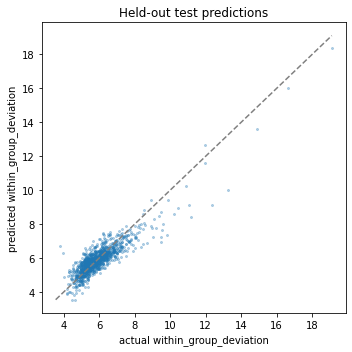

In [9]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_test, test_pred, s=4, alpha=0.3)
lims = [min(y_test.min(), test_pred.min()), max(y_test.max(), test_pred.max())]
ax.plot(lims, lims, color="gray", linestyle="--")
ax.set_xlabel("actual within_group_deviation")
ax.set_ylabel("predicted within_group_deviation")
ax.set_title("Held-out test predictions")
plt.tight_layout()
plt.show()